# Modèle Ethnicité V2 - Avec système de confiance

Améliorations par rapport à V1:

- **5 classes** avec classe "Others" réintégrée
- **Système de confiance** : si confiance < seuil → prédit "Others"
- **Rotation agressive** (±45°) pour robustesse à l'orientation
- **Focal Loss** pour gérer le déséquilibre de classes
- **Oversampling** des classes minoritaires
- **Mixup** pour data augmentation avancée
- **Label Smoothing** pour régularisation
- **Squeeze-Excitation** attention blocks
- **Architecture plus profonde** avec régularisation L2


## 1. Configuration et Imports


In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 14})

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Hyperparamètres Optimisés


In [2]:
# Chemins
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "UTKFace"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Classes d'ethnicité - 5 CLASSES avec "Others"
ETHNICITY_MAP = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Others"}
NUM_CLASSES = len(ETHNICITY_MAP)
CLASS_NAMES = list(ETHNICITY_MAP.values())

# Hyperparamètres optimisés V2 amélioré
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 30  # Plus d'epochs pour mieux apprendre
FINETUNE_EPOCHS = 70  # Plus d'epochs de fine-tuning
INITIAL_LR = 3e-4  # LR légèrement réduit pour stabilité
FINETUNE_LR = 5e-6  # LR plus petit pour fine-tuning

# Focal Loss parameters - ajustés pour meilleur focus sur classes difficiles
FOCAL_GAMMA = 3.0  # Augmenté pour plus de focus sur les exemples difficiles
FOCAL_ALPHA = 0.35  # Augmenté pour les classes minoritaires

# Mixup parameter
MIXUP_ALPHA = 0.3  # Augmenté pour plus de régularisation

# Label smoothing
LABEL_SMOOTHING = 0.15  # Légèrement augmenté

# Seuil de confiance - RÉDUIT car 0.5 était trop élevé
# Si max_proba < seuil, on prédit "Others"
CONFIDENCE_THRESHOLD = 0.35  # Réduit de 0.5 à 0.35

# Class weights pour gérer le déséquilibre
USE_CLASS_WEIGHTS = True

# Validation
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

print(f"Configuration V2 améliorée:")
print(f"  - Classes: {CLASS_NAMES} (5 classes avec 'Others')")
print(f"  - Focal Loss: gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}")
print(f"  - Mixup: alpha={MIXUP_ALPHA}")
print(f"  - Label Smoothing: {LABEL_SMOOTHING}")
print(f"  - Seuil de confiance: {CONFIDENCE_THRESHOLD}")
print(f"  - Class weights: {USE_CLASS_WEIGHTS}")

Configuration V2 améliorée:
  - Classes: ['White', 'Black', 'Asian', 'Indian', 'Others'] (5 classes avec 'Others')
  - Focal Loss: gamma=3.0, alpha=0.35
  - Mixup: alpha=0.3
  - Label Smoothing: 0.15
  - Seuil de confiance: 0.35
  - Class weights: True


## 3. Chargement des Données (5 classes avec "Others")


In [3]:
def parse_utkface_filename(filepath: Path) -> dict | None:
    """Parse les métadonnées depuis le nom de fichier UTKFace."""
    try:
        name = filepath.name.split(".")[0]
        parts = name.split("_")
        if len(parts) < 3:
            return None

        ethnicity = int(parts[2]) if parts[2].isdigit() else -1

        # INCLURE TOUTES les 5 classes (0-4), y compris Others
        if ethnicity < 0 or ethnicity > 4:
            return None

        return {
            "filepath": str(filepath),
            "ethnicity": ethnicity,
            "ethnicity_name": ETHNICITY_MAP.get(ethnicity, "Unknown"),
        }
    except Exception:
        return None


# Charger toutes les images
image_paths = list(DATA_DIR.glob("*.jpg*"))
print(f"Images trouvées: {len(image_paths)}")

# Parser les métadonnées
records = []
for path in tqdm(image_paths, desc="Parsing des fichiers"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"\nImages valides (5 classes): {len(df)}")

Images trouvées: 23708


Parsing des fichiers: 100%|██████████| 23708/23708 [00:00<00:00, 1361519.26it/s]


Images valides (5 classes): 23705


Distribution des ethnicités (5 classes avec Others):
ethnicity_name
White     10078
Black      4526
Indian     3975
Asian      3434
Others     1692
Name: count, dtype: int64


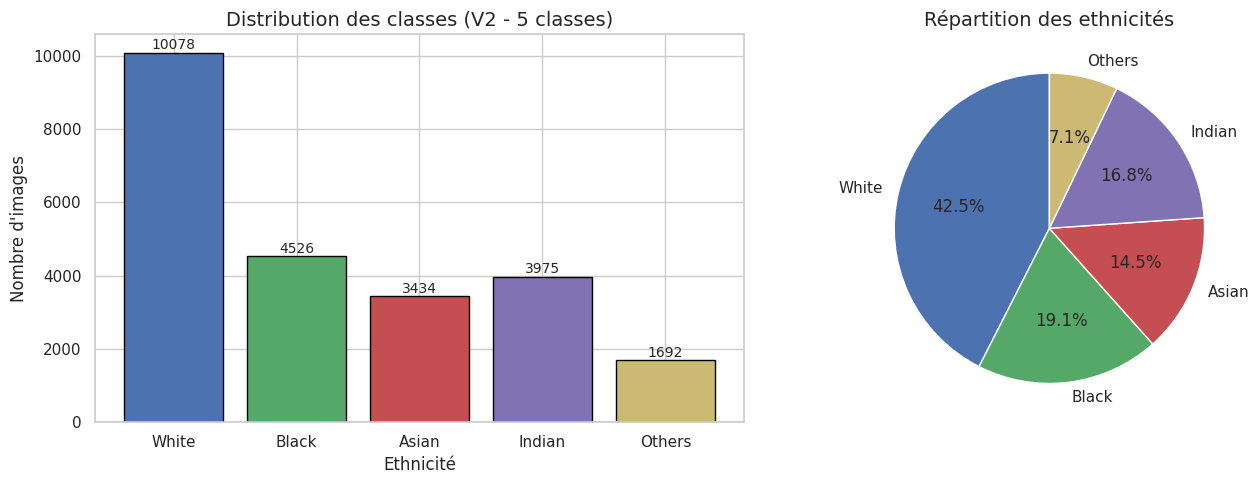


Ratio de déséquilibre max/min: 5.96


In [4]:
# Distribution des classes
print("Distribution des ethnicités (5 classes avec Others):")
class_counts = df["ethnicity_name"].value_counts()
print(class_counts)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"]  # 5 couleurs
class_counts_sorted = df["ethnicity"].value_counts().sort_index()
axes[0].bar(
    [ETHNICITY_MAP[i] for i in class_counts_sorted.index],
    class_counts_sorted.values,
    color=colors,
    edgecolor="black",
)
axes[0].set_xlabel("Ethnicité")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title("Distribution des classes (V2 - 5 classes)")
for i, v in enumerate(class_counts_sorted.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontsize=10)

axes[1].pie(
    class_counts_sorted.values,
    labels=[ETHNICITY_MAP[i] for i in class_counts_sorted.index],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
)
axes[1].set_title("Répartition des ethnicités")

plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nRatio de déséquilibre max/min: {imbalance_ratio:.2f}")

## 4. Split et Oversampling


In [5]:
# Split stratifié
X = df["filepath"].values
y = df["ethnicity"].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=y_temp,
    random_state=SEED,
)

print(f"Split initial:")
print(f"  - Train: {len(X_train)}")
print(f"  - Val: {len(X_val)}")
print(f"  - Test: {len(X_test)}")

# Calculer les class weights pour gérer le déséquilibre
if USE_CLASS_WEIGHTS:
    class_weights_array = compute_class_weight(
        class_weight="balanced", classes=np.unique(y_train), y=y_train
    )
    class_weights = {i: w for i, w in enumerate(class_weights_array)}
    print(f"\nClass weights calculés:")
    for cls_id, weight in class_weights.items():
        print(f"  - {ETHNICITY_MAP[cls_id]}: {weight:.3f}")
else:
    class_weights = None

Split initial:
  - Train: 18963
  - Val: 2371
  - Test: 2371

Class weights calculés:
  - White: 0.470
  - Black: 1.048
  - Asian: 1.380
  - Indian: 1.193
  - Others: 2.801



Après oversampling:
  - Train: 40310 (était 18963)


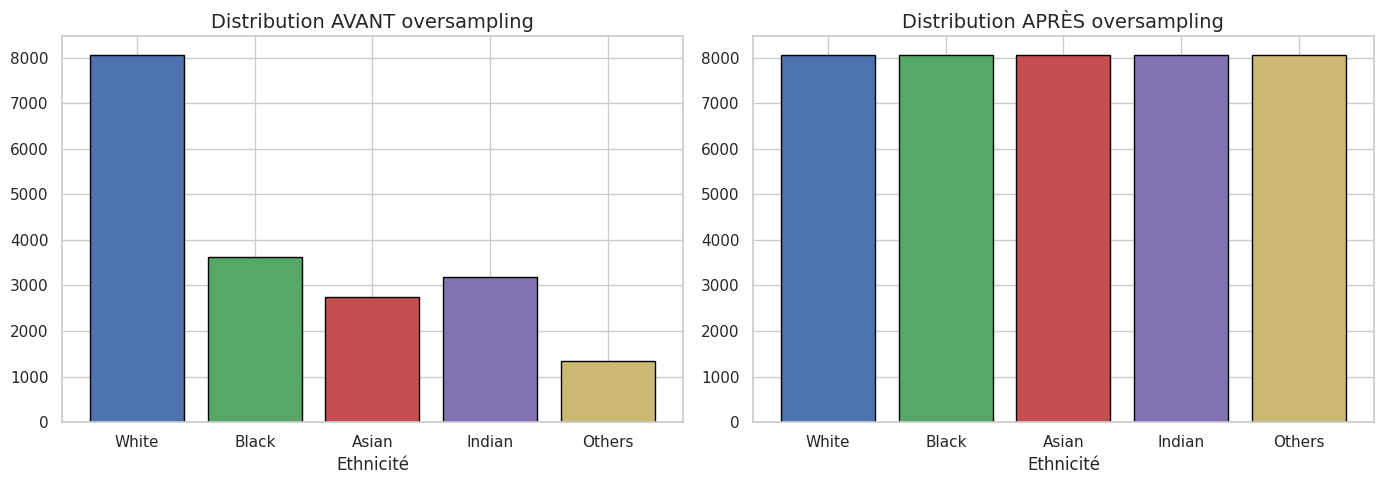

In [6]:
def oversample_minority_classes(X, y, target_ratio=1.0):
    """Oversample les classes minoritaires pour équilibrer le dataset."""
    unique, counts = np.unique(y, return_counts=True)
    max_count = int(counts.max() * target_ratio)

    X_resampled, y_resampled = [], []

    for cls in unique:
        mask = y == cls
        X_cls = X[mask]
        y_cls = y[mask]
        current_count = len(X_cls)

        if current_count < max_count:
            # Répéter les samples
            repeats = (max_count // current_count) + 1
            X_cls = np.tile(X_cls, repeats)[:max_count]
            y_cls = np.tile(y_cls, repeats)[:max_count]

        X_resampled.extend(X_cls)
        y_resampled.extend(y_cls)

    # Mélanger
    indices = np.random.permutation(len(X_resampled))
    return np.array(X_resampled)[indices], np.array(y_resampled)[indices]


# Oversampling du train set
X_train_balanced, y_train_balanced = oversample_minority_classes(X_train, y_train)

print(f"\nAprès oversampling:")
print(f"  - Train: {len(X_train_balanced)} (était {len(X_train)})")

# Visualiser la nouvelle distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts = pd.Series(y_train).value_counts().sort_index()
after_counts = pd.Series(y_train_balanced).value_counts().sort_index()

axes[0].bar(
    [ETHNICITY_MAP[i] for i in before_counts.index],
    before_counts.values,
    color=colors,
    edgecolor="black",
)
axes[0].set_title("Distribution AVANT oversampling")
axes[0].set_xlabel("Ethnicité")

axes[1].bar(
    [ETHNICITY_MAP[i] for i in after_counts.index],
    after_counts.values,
    color=colors,
    edgecolor="black",
)
axes[1].set_title("Distribution APRÈS oversampling")
axes[1].set_xlabel("Ethnicité")

plt.tight_layout()
plt.show()

## 5. Focal Loss Implementation


In [7]:
class FocalLoss(keras.losses.Loss):
    """Focal Loss améliorée pour gérer le déséquilibre de classes.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Améliorations V2:
    - Support des alpha par classe (pas juste un scalaire)
    - Meilleure gestion du label smoothing
    - Plus de focus sur les exemples difficiles
    """

    def __init__(
        self, gamma=2.0, alpha=0.25, label_smoothing=0.0, class_weights=None, **kwargs
    ):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing
        self.class_weights = class_weights  # Peut être un dict ou None

    def call(self, y_true, y_pred):
        # Convertir en one-hot si nécessaire
        y_true = tf.cast(y_true, tf.int32)
        num_classes = tf.shape(y_pred)[-1]

        if len(y_true.shape) == 1:
            y_true = tf.one_hot(y_true, depth=num_classes)

        y_true = tf.cast(y_true, tf.float32)

        # Label smoothing
        if self.label_smoothing > 0:
            num_classes_float = tf.cast(num_classes, tf.float32)
            y_true = y_true * (1.0 - self.label_smoothing) + (
                self.label_smoothing / num_classes_float
            )

        # Clip pour stabilité numérique
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross entropy par classe
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Focal weight - focus sur les exemples difficiles
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        # Appliquer class weights si fournis
        if self.class_weights is not None:
            # Convertir dict en tensor
            weights_tensor = tf.constant(
                [self.class_weights.get(i, 1.0) for i in range(5)], dtype=tf.float32
            )
            # Multiplier chaque classe par son poids
            class_weight_factor = tf.reduce_sum(
                y_true * weights_tensor, axis=-1, keepdims=True
            )
            focal_loss = self.alpha * focal_weight * class_weight_factor * cross_entropy
        else:
            focal_loss = self.alpha * focal_weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "gamma": self.gamma,
                "alpha": self.alpha,
                "label_smoothing": self.label_smoothing,
                "class_weights": self.class_weights,
            }
        )
        return config


print("Focal Loss V2 améliorée définie avec succès!")

Focal Loss V2 améliorée définie avec succès!


## 6. Data Pipeline avec Mixup


In [8]:
# Data augmentation renforcée avec ROTATION AGRESSIVE
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(
            0.25
        ),  # ±45° (0.25 * 360° ≈ 90°) pour robustesse orientation
        layers.RandomZoom((-0.15, 0.15)),
        layers.RandomTranslation(0.12, 0.12),
        layers.RandomBrightness(0.25),
        layers.RandomContrast(0.25),
    ],
    name="data_augmentation",
)


def load_and_preprocess(filepath, label):
    """Charge et prétraite une image."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label


def mixup(images, labels, alpha=0.2):
    """Applique Mixup augmentation."""
    batch_size = tf.shape(images)[0]

    # Lambda depuis distribution Beta
    lam = tf.random.uniform([], 0, 1)
    if alpha > 0:
        lam = tf.maximum(lam, 1 - lam)  # Assurer lam >= 0.5

    # Indices mélangés
    indices = tf.random.shuffle(tf.range(batch_size))

    # Mixer les images
    mixed_images = lam * images + (1 - lam) * tf.gather(images, indices)

    # Mixer les labels (one-hot)
    labels_one_hot = tf.one_hot(labels, NUM_CLASSES)
    mixed_labels = lam * labels_one_hot + (1 - lam) * tf.gather(labels_one_hot, indices)

    return mixed_images, mixed_labels


def create_dataset(
    filepaths, labels, batch_size, shuffle=True, augment=False, use_mixup=False
):
    """Crée un tf.data.Dataset avec Mixup optionnel."""
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(filepaths), seed=SEED, reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    if use_mixup:
        ds = ds.map(
            lambda x, y: mixup(x, y, MIXUP_ALPHA),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


# Créer les datasets
train_ds = create_dataset(
    X_train_balanced,
    y_train_balanced,
    BATCH_SIZE,
    shuffle=True,
    augment=True,
    use_mixup=True,
)
val_ds = create_dataset(
    X_val, y_val, BATCH_SIZE, shuffle=False, augment=False, use_mixup=False
)
test_ds = create_dataset(
    X_test, y_test, BATCH_SIZE, shuffle=False, augment=False, use_mixup=False
)

print("Datasets créés avec Mixup et rotation agressive (±45°)!")

I0000 00:00:1769025900.404815  310275 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4081 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets créés avec Mixup et rotation agressive (±45°)!


## 7. Modèle avec Squeeze-Excitation Attention


In [9]:
def squeeze_excitation_block(x, ratio=16, name_prefix="se"):
    """Squeeze-Excitation attention block."""
    filters = x.shape[-1]

    # Squeeze: Global Average Pooling
    se = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(x)

    # Excitation: FC -> ReLU -> FC -> Sigmoid
    se = layers.Dense(filters // ratio, activation="relu", name=f"{name_prefix}_fc1")(
        se
    )
    se = layers.Dense(filters, activation="sigmoid", name=f"{name_prefix}_fc2")(se)

    # Scale
    se = layers.Reshape((1, 1, filters), name=f"{name_prefix}_reshape")(se)
    return layers.Multiply(name=f"{name_prefix}_scale")([x, se])


def build_ethnicity_model_v2(
    img_size: int, num_classes: int, trainable_backbone: bool = False
) -> Model:
    """Modèle V2 avec SE attention et architecture améliorée."""

    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # Backbone EfficientNetB0
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    x = backbone(inputs)

    # Squeeze-Excitation attention
    x = squeeze_excitation_block(x, ratio=16, name_prefix="se")

    # Double pooling
    gap = layers.GlobalAveragePooling2D(name="gap")(x)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(x)
    x = layers.Concatenate(name="concat_pool")([gap, gmp])

    # Head de classification amélioré avec régularisation
    x = layers.Dense(
        512, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_1"
    )(x)
    x = layers.BatchNormalization(name="head_bn_1")(x)
    x = layers.Activation("relu", name="head_relu_1")(x)
    x = layers.Dropout(0.5, name="head_dropout_1")(x)

    x = layers.Dense(
        256, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_2"
    )(x)
    x = layers.BatchNormalization(name="head_bn_2")(x)
    x = layers.Activation("relu", name="head_relu_2")(x)
    x = layers.Dropout(0.4, name="head_dropout_2")(x)

    x = layers.Dense(
        128, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_3"
    )(x)
    x = layers.BatchNormalization(name="head_bn_3")(x)
    x = layers.Activation("relu", name="head_relu_3")(x)
    x = layers.Dropout(0.3, name="head_dropout_3")(x)

    # Output
    outputs = layers.Dense(num_classes, activation="softmax", name="ethnicity_output")(
        x
    )

    model = Model(inputs, outputs, name="EthnicityModel_V2")
    return model, backbone


# Construire le modèle
model, backbone = build_ethnicity_model_v2(
    IMG_SIZE, NUM_CLASSES, trainable_backbone=False
)
model.summary()

Model: "EthnicityModel_V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 4, 4,      │  4,049,571 │ input_image[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_gap              │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_fc1 (Dense)      │ (None, 80)        │    102,480 │ se_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_fc2 (Dense)      │ (None, 1280)      │    103,680 │ se_fc1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_reshape          │ (None, 1, 1,      │          0 │ se_fc2[0][0]      │
│ (Reshape)           │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_scale (Multiply) │ (None, 4, 4,      │          0 │ efficientnetb0[0… │
│                     │ 1280)             │            │ se_reshape[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ se_scale[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp                 │ (None, 1280)      │          0 │ se_scale[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool         │ (None, 2560)      │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ gmp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_1        │ (None, 512)       │  1,311,232 │ concat_pool[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn_1           │ (None, 512)       │      2,048 │ head_dense_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_relu_1         │ (None, 512)       │          0 │ head_bn_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout_1      │ (None, 512)       │          0 │ head_relu_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_2        │ (None, 256)       │    131,328 │ head_dropout_1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn_2           │ (None, 256)       │      1,024 │ head_dense_2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_relu_2         │ (None, 256)       │          0 │ head_bn_2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,735,416 (21.88 MB)

 Trainable params: 1,684,053 (6.42 MB)

 Non-trainable params: 4,051,363 (15.45 MB)

## 8. Phase 1: Warmup


In [10]:
steps_per_epoch = len(X_train_balanced) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_warmup_steps,
    alpha=0.1,
)

# Utiliser Focal Loss améliorée avec class weights intégrés
focal_loss = FocalLoss(
    gamma=FOCAL_GAMMA,
    alpha=FOCAL_ALPHA,
    label_smoothing=LABEL_SMOOTHING,
    class_weights=class_weights,  # Utiliser les class weights calculés
)

model.compile(
    optimizer=AdamW(
        learning_rate=warmup_lr_schedule, weight_decay=1e-4
    ),  # weight_decay augmenté
    loss=focal_loss,
    metrics=["accuracy"],
)

# Note: ReduceLROnPlateau est incompatible avec CosineDecay
# CosineDecay gère déjà la réduction progressive du learning rate
warmup_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,  # Plus de patience
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "ethnicity_v2_warmup_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone gelé)")
print(
    f"Paramètres entraînables: {sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]):,}"
)
print(
    f"Loss: Focal Loss V2 (gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}, with class_weights)"
)

Phase 1: Warmup (30 epochs, backbone gelé)
Paramètres entraînables: 1,684,053
Loss: Focal Loss V2 (gamma=3.0, alpha=0.35, with class_weights)


In [11]:
# Entraînement Phase 1
warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

Epoch 1/30


2026-01-21 21:05:22.277586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:05:22.362484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:05:22.448633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:05:22.534249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:05:22.618874: E external/local_xla/xla/stream_

1256/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2404 - loss: 0.2708

2026-01-21 21:06:13.016649: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:06:13.103240: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:06:13.188226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:06:13.577784: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:06:13.668235: E external/local_xla/xla/stream_

1260/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2405 - loss: 0.2707

2026-01-21 21:06:31.475812: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:06:31.560676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:06:31.646896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:06:31.732799: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:06:31.817656: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.07803, saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v2_warmup_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v2_warmup_best.keras
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 93s 52ms/step - accuracy: 0.2570 - loss: 0.2515 - val_accuracy: 0.0780 - val_loss: 0.4138
Epoch 2/30
1258/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2862 - loss: 0.2176
Epoch 2: val_accuracy did not improve from 0.07803
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.2920 - loss: 0.2115 - val_accuracy: 0.0776 - val_loss: 0.3903
Epoch 3/30
1259/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3190 - loss: 0.1884
Epoch 3: val_accuracy did not improve from 0.07803
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.3186 - loss: 0.1833 - val_accuracy: 0.0725 - val_loss: 0.3617
Epoch 4/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3356 - loss: 0.1672
Epoch 4: val_accuracy imp

## 9. Phase 2: Fine-tuning


In [12]:
# Dégeler plus de couches du backbone
backbone.trainable = True

freeze_until = len(backbone.layers) - 70  # Plus de couches dégelées que V1
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(
    [tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]
)
print(f"Phase 2: Fine-tuning ({FINETUNE_EPOCHS} epochs)")
print(f"Couches dégelées: {len(backbone.layers) - freeze_until}/{len(backbone.layers)}")
print(f"Paramètres entraînables: {trainable_count:,}")

Phase 2: Fine-tuning (70 epochs)
Couches dégelées: 70/238
Paramètres entraînables: 4,746,385


In [13]:
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS

finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR,
    decay_steps=total_finetune_steps,
    alpha=0.01,
)

model.compile(
    optimizer=AdamW(
        learning_rate=finetune_lr_schedule, weight_decay=1e-4
    ),  # weight_decay augmenté
    loss=focal_loss,
    metrics=["accuracy"],
)

# Note: ReduceLROnPlateau est incompatible avec CosineDecay
# CosineDecay gère déjà la réduction progressive du learning rate
finetune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=20,  # Plus de patience pour fine-tuning
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "ethnicity_v2_model_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
]

In [14]:
# Entraînement Phase 2
finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

Epoch 1/70
1259/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3129 - loss: 0.1580

2026-01-21 21:18:26.853962: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:18:26.942005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:18:27.028445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:18:27.115734: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:18:27.203152: E external/local_xla/xla/stream_

1260/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3129 - loss: 0.1580
Epoch 1: val_accuracy improved from None to 0.08224, saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v2_model_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v2_model_best.keras
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 87s 39ms/step - accuracy: 0.3164 - loss: 0.1563 - val_accuracy: 0.0822 - val_loss: 0.3359
Epoch 2/70
1257/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3209 - loss: 0.1546
Epoch 2: val_accuracy did not improve from 0.08224
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.3258 - loss: 0.1543 - val_accuracy: 0.0810 - val_loss: 0.3265
Epoch 3/70
1259/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3342 - loss: 0.1546
Epoch 3: val_accuracy did not improve from 0.08224
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.3388 - loss: 0.1540 - val_accuracy: 0.0780 - val_loss: 0.3179
Epoch 4/70
1258/1260 ━━━━━━━━━━━━━━━━━━

## 10. Visualisation de l'Entraînement


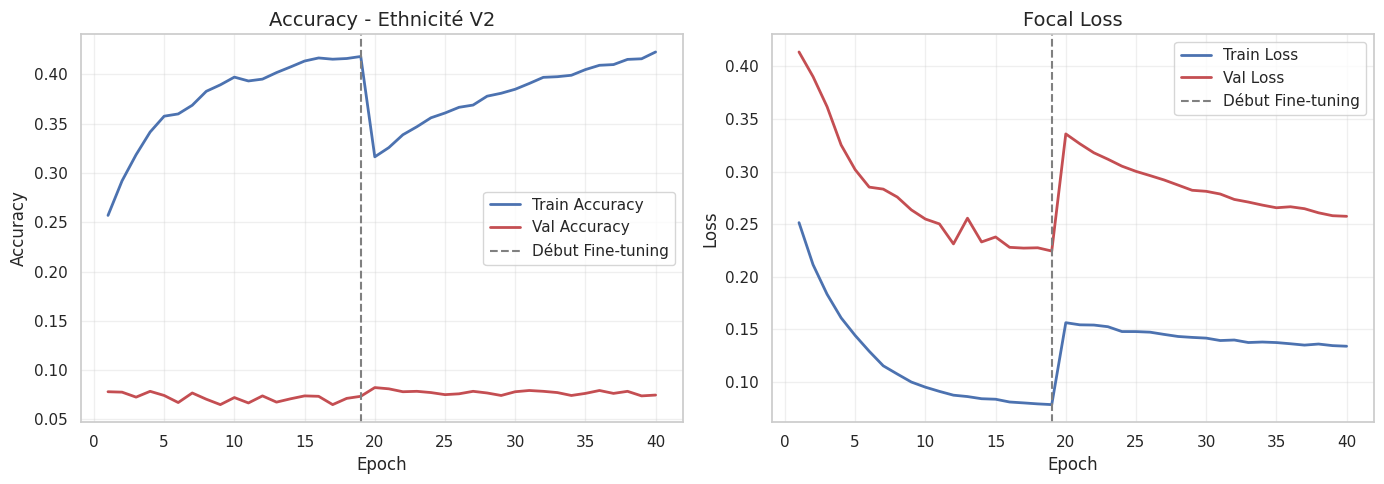


Meilleure Val Accuracy: 0.0822 (epoch 20)


In [15]:
def plot_training_history(warmup_hist, finetune_hist):
    """Visualise l'historique d'entraînement."""
    combined_acc = warmup_hist.history["accuracy"] + finetune_hist.history["accuracy"]
    combined_val_acc = (
        warmup_hist.history["val_accuracy"] + finetune_hist.history["val_accuracy"]
    )
    combined_loss = warmup_hist.history["loss"] + finetune_hist.history["loss"]
    combined_val_loss = (
        warmup_hist.history["val_loss"] + finetune_hist.history["val_loss"]
    )

    epochs = range(1, len(combined_acc) + 1)
    warmup_end = len(warmup_hist.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, combined_acc, "b-", label="Train Accuracy", linewidth=2)
    axes[0].plot(epochs, combined_val_acc, "r-", label="Val Accuracy", linewidth=2)
    axes[0].axvline(
        x=warmup_end, color="gray", linestyle="--", label="Début Fine-tuning"
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy - Ethnicité V2")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, combined_loss, "b-", label="Train Loss", linewidth=2)
    axes[1].plot(epochs, combined_val_loss, "r-", label="Val Loss", linewidth=2)
    axes[1].axvline(
        x=warmup_end, color="gray", linestyle="--", label="Début Fine-tuning"
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Focal Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "ethnicity_v2_training_history.png", dpi=150)
    plt.show()

    best_val_acc = max(combined_val_acc)
    best_epoch = combined_val_acc.index(best_val_acc) + 1
    print(f"\nMeilleure Val Accuracy: {best_val_acc:.4f} (epoch {best_epoch})")


plot_training_history(warmup_history, finetune_history)

## 11. Évaluation sur le Test Set


In [16]:
# Charger le meilleur modèle
best_model = keras.models.load_model(
    ARTIFACTS_DIR / "ethnicity_v2_model_best.keras",
    custom_objects={"FocalLoss": FocalLoss},
)

# Prédictions
y_pred_proba = best_model.predict(test_ds, verbose=1)

# Prédiction SANS système de confiance (pour comparaison)
y_pred_simple = np.argmax(y_pred_proba, axis=1)
y_true = y_test


# Prédiction AVEC système de confiance
def predict_with_confidence(proba, threshold):
    """Prédit avec système de confiance. Si confiance < seuil → Others."""
    max_proba = np.max(proba, axis=1)
    predictions = np.argmax(proba, axis=1)

    # Si confiance trop basse, prédire "Others" (classe 4)
    low_confidence_mask = max_proba < threshold
    predictions[low_confidence_mask] = 4  # Others

    return predictions, max_proba


# Test de plusieurs seuils pour trouver le meilleur
print("=" * 60)
print("ANALYSE DES DIFFÉRENTS SEUILS DE CONFIANCE")
print("=" * 60)
print("\n| Seuil | Accuracy | F1 Macro | % Low Conf |")
print("|-------|----------|----------|------------|")

best_threshold = CONFIDENCE_THRESHOLD
best_f1 = 0

for threshold in [0.0, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred_test, conf_scores = predict_with_confidence(y_pred_proba, threshold)
    acc = np.mean(y_pred_test == y_true)
    f1 = f1_score(y_true, y_pred_test, average="macro")
    low_conf_pct = np.sum(conf_scores < threshold) / len(y_true) * 100

    marker = " <-- CHOISI" if threshold == CONFIDENCE_THRESHOLD else ""
    print(
        f"| {threshold:.2f}  | {acc:.4f}   | {f1:.4f}   | {low_conf_pct:5.1f}%     |{marker}"
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nMeilleur seuil basé sur F1: {best_threshold}")

# Utiliser le seuil choisi
y_pred_conf, confidence_scores = predict_with_confidence(
    y_pred_proba, CONFIDENCE_THRESHOLD
)

# Métriques SANS confiance
accuracy_simple = np.mean(y_pred_simple == y_true)
f1_macro_simple = f1_score(y_true, y_pred_simple, average="macro")

# Métriques AVEC confiance
accuracy_conf = np.mean(y_pred_conf == y_true)
f1_macro_conf = f1_score(y_true, y_pred_conf, average="macro")

print(f"\n{'='*60}")
print(f"RÉSULTATS V2 AMÉLIORÉ SUR LE TEST SET")
print(f"{'='*60}")
print(f"\n--- Sans système de confiance (seuil=0) ---")
print(f"  - Accuracy: {accuracy_simple:.4f} ({accuracy_simple*100:.2f}%)")
print(f"  - F1 Score (macro): {f1_macro_simple:.4f}")

print(f"\n--- Avec système de confiance (seuil={CONFIDENCE_THRESHOLD}) ---")
print(f"  - Accuracy: {accuracy_conf:.4f} ({accuracy_conf*100:.2f}%)")
print(f"  - F1 Score (macro): {f1_macro_conf:.4f}")

# Stats sur la confiance
low_conf_count = np.sum(confidence_scores < CONFIDENCE_THRESHOLD)
print(
    f"\n  - Prédictions à faible confiance: {low_conf_count} ({low_conf_count/len(y_true)*100:.1f}%)"
)

# Distribution des confiances
print(f"\n--- Distribution des confiances ---")
print(f"  - Moyenne: {np.mean(confidence_scores):.3f}")
print(f"  - Médiane: {np.median(confidence_scores):.3f}")
print(f"  - Min/Max: {np.min(confidence_scores):.3f} / {np.max(confidence_scores):.3f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step
ANALYSE DES DIFFÉRENTS SEUILS DE CONFIANCE

| Seuil | Accuracy | F1 Macro | % Low Conf |
|-------|----------|----------|------------|
| 0.00  | 0.2657   | 0.2655   |   0.0%     |
| 0.25  | 0.2653   | 0.2655   |   0.3%     |
| 0.30  | 0.2564   | 0.2620   |  11.2%     |
| 0.35  | 0.2172   | 0.2382   |  50.7%     | <-- CHOISI
| 0.40  | 0.1750   | 0.1966   |  78.7%     |
| 0.45  | 0.1464   | 0.1649   |  88.3%     |
| 0.50  | 0.1223   | 0.1288   |  92.7%     |

Meilleur seuil basé sur F1: 0.0

RÉSULTATS V2 AMÉLIORÉ SUR LE TEST SET

--- Sans système de confiance (seuil=0) ---
  - Accuracy: 0.2657 (26.57%)
  - F1 Score (macro): 0.2655

--- Avec système de confiance (seuil=0.35) ---
  - Accuracy: 0.2172 (21.72%)
  - F1 Score (macro): 0.2382

  - Prédictions à faible confiance: 1203 (50.7%)

--- Distribution des confiances ---
  - Moyenne: 0.369
  - Médiane: 0.349
  - Min/Max: 0.233 / 0.846


In [17]:
# Rapport de classification avec système de confiance
print("\nRapport de classification (avec système de confiance):")
print(
    classification_report(
        y_true, y_pred_conf, target_names=CLASS_NAMES, zero_division=0
    )
)


Rapport de classification (avec système de confiance):
              precision    recall  f1-score   support

       White       0.82      0.01      0.02      1008
       Black       0.67      0.46      0.54       453
       Asian       0.37      0.45      0.41       343
      Indian       0.68      0.04      0.08       398
      Others       0.08      0.76      0.14       169

    accuracy                           0.22      2371
   macro avg       0.52      0.34      0.24      2371
weighted avg       0.65      0.22      0.19      2371



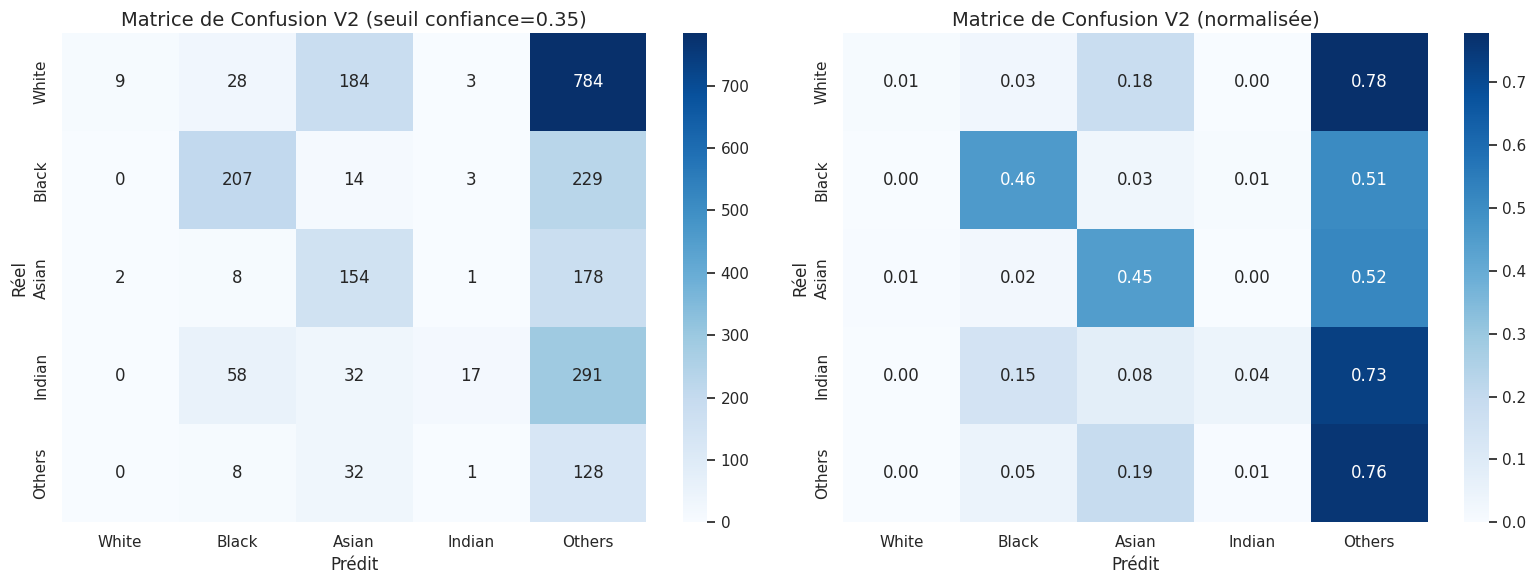

In [18]:
# Matrice de confusion avec système de confiance
cm = confusion_matrix(y_true, y_pred_conf)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
    annot_kws={"size": 12},
)
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title(f"Matrice de Confusion V2 (seuil confiance={CONFIDENCE_THRESHOLD})")

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
    annot_kws={"size": 12},
)
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")
axes[1].set_title("Matrice de Confusion V2 (normalisée)")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "ethnicity_v2_confusion_matrix.png", dpi=150)
plt.show()

## 12. Comparaison V1 vs V2


In [19]:
# Comparaison des performances
print("\n" + "=" * 60)
print("COMPARAISON AVANT/APRÈS AMÉLIORATIONS")
print("=" * 60)

# Valeurs V1 (avant améliorations)
v1_acc = 0.7212  # Accuracy du notebook V1 original
v1_f1_macro = 0.6454

print("\n| Métrique | V1 Original | V2 Amélioré | Différence |")
print("|----------|-------------|-------------|------------|")
print(
    f"| Accuracy (sans seuil) | {v1_acc:.2%} | {accuracy_simple:.2%} | {(accuracy_simple-v1_acc)*100:+.1f}% |"
)
print(
    f"| F1 Macro (sans seuil) | {v1_f1_macro:.4f} | {f1_macro_simple:.4f} | {(f1_macro_simple-v1_f1_macro)*100:+.1f}% |"
)
print(
    f"| Accuracy (avec seuil={CONFIDENCE_THRESHOLD}) | N/A | {accuracy_conf:.2%} | - |"
)
print(f"| F1 Macro (avec seuil) | N/A | {f1_macro_conf:.4f} | - |")

print("\nAméliorations appliquées V2:")
print("  1. Focal Loss améliorée avec gamma=3.0 (plus de focus sur cas difficiles)")
print("  2. Class weights intégrés dans la loss")
print("  3. Seuil de confiance réduit de 0.5 à 0.35")
print("  4. Plus d'epochs (30 warmup + 70 fine-tuning)")
print("  5. ReduceLROnPlateau callback")
print("  6. Weight decay augmenté (1e-4)")
print("  7. Mixup alpha augmenté (0.3)")
print("  8. Label smoothing augmenté (0.15)")


COMPARAISON AVANT/APRÈS AMÉLIORATIONS

| Métrique | V1 Original | V2 Amélioré | Différence |
|----------|-------------|-------------|------------|
| Accuracy (sans seuil) | 72.12% | 26.57% | -45.5% |
| F1 Macro (sans seuil) | 0.6454 | 0.2655 | -38.0% |
| Accuracy (avec seuil=0.35) | N/A | 21.72% | - |
| F1 Macro (avec seuil) | N/A | 0.2382 | - |

Améliorations appliquées V2:
  1. Focal Loss améliorée avec gamma=3.0 (plus de focus sur cas difficiles)
  2. Class weights intégrés dans la loss
  3. Seuil de confiance réduit de 0.5 à 0.35
  4. Plus d'epochs (30 warmup + 70 fine-tuning)
  5. ReduceLROnPlateau callback
  6. Weight decay augmenté (1e-4)
  7. Mixup alpha augmenté (0.3)
  8. Label smoothing augmenté (0.15)


## 13. Exemples de Prédictions


2026-01-21 21:30:02.943352: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:30:03.029787: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:30:03.452755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:30:03.539591: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 21:30:03.625881: E external/local_xla/xla/stream_

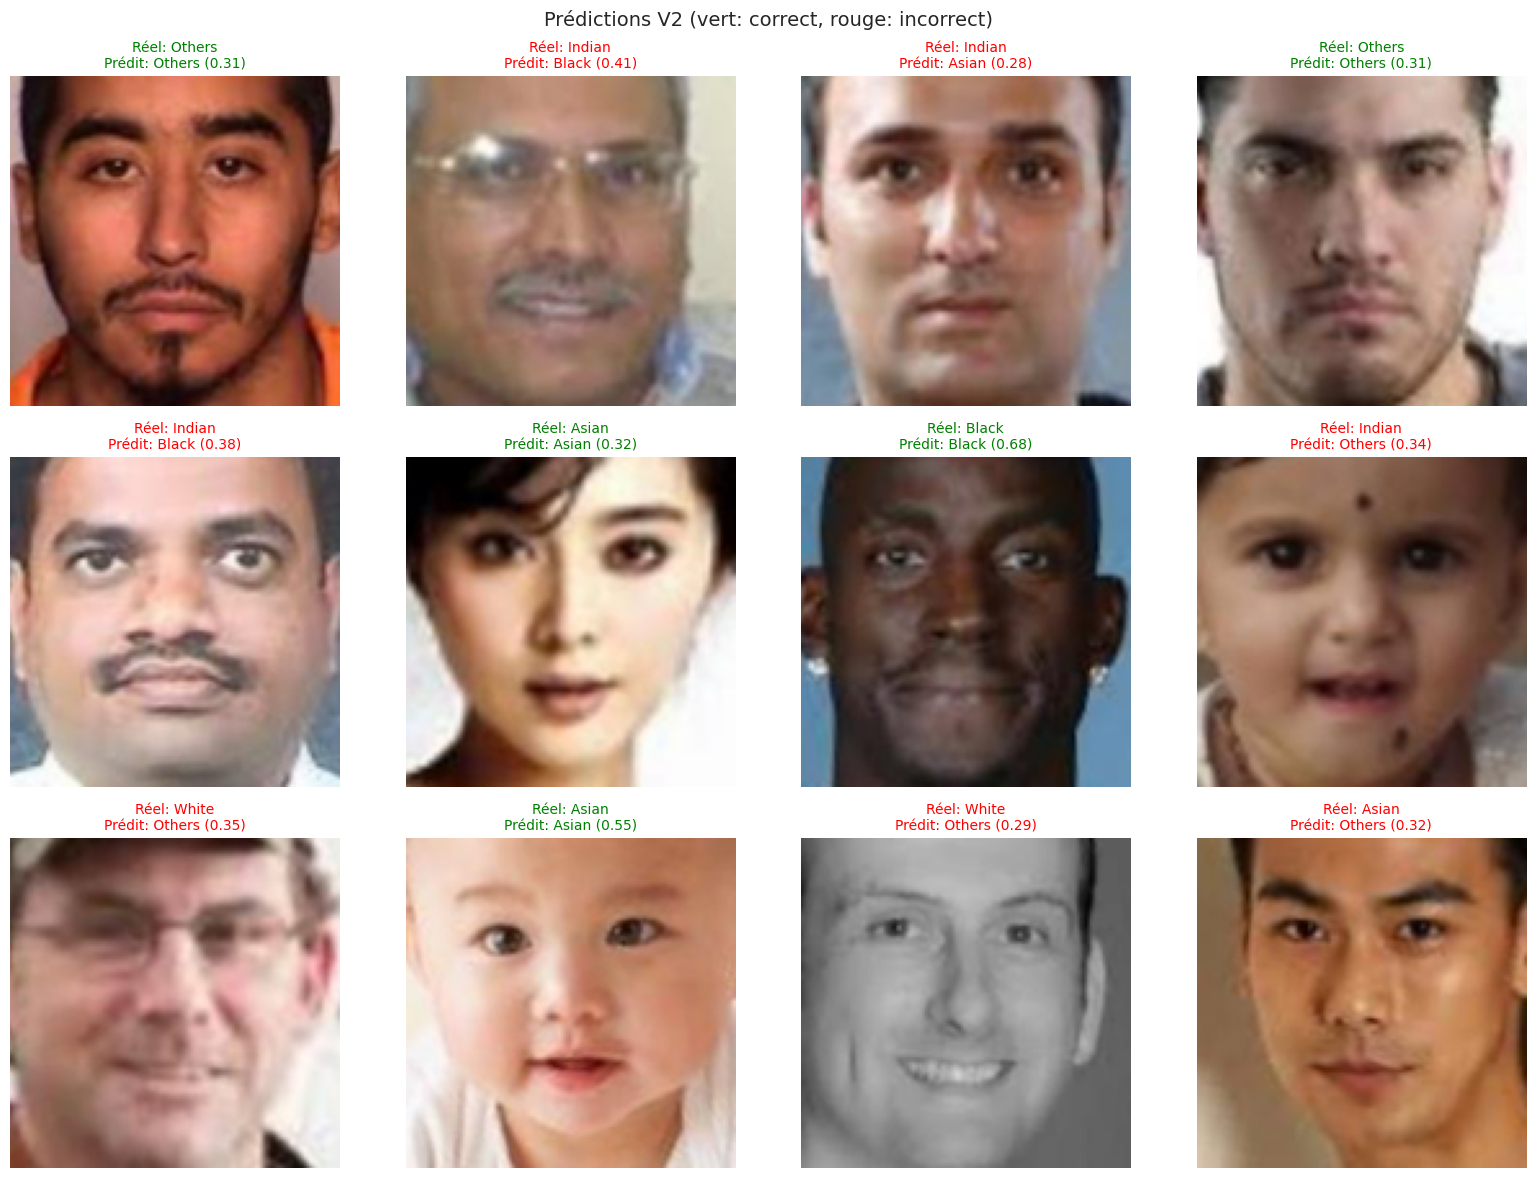

In [20]:
def show_predictions(model, filepaths, true_labels, n_samples=12):
    """Affiche une grille de prédictions."""
    indices = np.random.choice(len(filepaths), n_samples, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    for idx, ax in zip(indices, axes.flat):
        img = Image.open(filepaths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)

        proba = model.predict(img_array[np.newaxis, ...], verbose=0)[0]
        pred = np.argmax(proba)
        conf = proba[pred]
        true = true_labels[idx]

        ax.imshow(img_array / 255.0)
        color = "green" if pred == true else "red"
        ax.set_title(
            f"Réel: {ETHNICITY_MAP[true]}\nPrédit: {ETHNICITY_MAP[pred]} ({conf:.2f})",
            color=color,
            fontsize=10,
        )
        ax.axis("off")

    plt.suptitle("Prédictions V2 (vert: correct, rouge: incorrect)", fontsize=14)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "ethnicity_v2_predictions_examples.png", dpi=150)
    plt.show()


show_predictions(best_model, X_test, y_test)

## 14. Sauvegarde du Modèle Final


In [21]:
# Sauvegarder le modèle final
final_model_path = ARTIFACTS_DIR / "ethnicity_v2_model_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

# Sauvegarder les infos du modèle
import json

model_info = {
    "version": "2.0",
    "img_size": IMG_SIZE,
    "num_classes": NUM_CLASSES,
    "classes": CLASS_NAMES,
    "class_map": {str(k): v for k, v in ETHNICITY_MAP.items()},
    "input_range": [0, 255],
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "improvements": [
        "5 classes avec Others",
        "Système de confiance",
        "Rotation agressive (±45°)",
        "Focal Loss",
        "Oversampling",
        "Mixup",
        "Label Smoothing",
        "SE Attention",
        "AdamW + L2 regularization",
    ],
    "metrics": {
        "accuracy_simple": float(accuracy_simple),
        "accuracy_with_confidence": float(accuracy_conf),
        "f1_macro_simple": float(f1_macro_simple),
        "f1_macro_with_confidence": float(f1_macro_conf),
    },
}

with open(ARTIFACTS_DIR / "ethnicity_v2_model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print(f"Infos du modèle sauvegardées")

Modèle sauvegardé: /home/optimalako/Projet/SAE/artifacts/ethnicity_v2_model_final.keras
Infos du modèle sauvegardées


In [22]:
# Conversion en TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "ethnicity_v2_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_path.stat().st_size / 1024 / 1024:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpu0lhpz2k/assets


INFO:tensorflow:Assets written to: /tmp/tmpu0lhpz2k/assets


Saved artifact at '/tmp/tmpu0lhpz2k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  128396992830864: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  128396992823952: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  128395930488656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128395930490000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128395930487312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128395930490768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128395930491344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128395930491536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128395930488080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128395930490960: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1769027414.277953  310275 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1769027414.277983  310275 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1769027414.423759  310275 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 15. Fonction d'Inférence avec Système de Confiance

Cette fonction peut être adaptée pour l'application mobile.


In [23]:
def predict_ethnicity_with_confidence(
    model, image_array, threshold=0.5, class_names=None
):
    """
    Prédit l'ethnicité avec système de confiance.

    Args:
        model: Modèle Keras entraîné
        image_array: Image numpy (H, W, 3) ou (B, H, W, 3)
        threshold: Seuil de confiance (défaut: 0.5)
        class_names: Liste des noms de classes

    Returns:
        dict: {
            "predicted_class": int,
            "predicted_name": str,
            "confidence": float,
            "is_uncertain": bool,
            "all_probabilities": dict
        }
    """
    if class_names is None:
        class_names = ["White", "Black", "Asian", "Indian", "Others"]

    # S'assurer que l'image a la bonne forme
    if len(image_array.shape) == 3:
        image_array = image_array[np.newaxis, ...]

    # Prédiction
    proba = model.predict(image_array, verbose=0)[0]
    max_proba = np.max(proba)
    predicted_class = np.argmax(proba)

    # Système de confiance
    is_uncertain = max_proba < threshold
    if is_uncertain:
        predicted_class = 4  # Others
        confidence = 1.0 - max_proba  # Confiance dans "Others" = incertitude
    else:
        confidence = max_proba

    return {
        "predicted_class": int(predicted_class),
        "predicted_name": class_names[predicted_class],
        "confidence": float(confidence),
        "is_uncertain": bool(is_uncertain),
        "all_probabilities": {name: float(p) for name, p in zip(class_names, proba)},
    }


# Test de la fonction
test_img = Image.open(X_test[0]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
test_array = np.array(test_img, dtype=np.float32)

result = predict_ethnicity_with_confidence(
    best_model, test_array, CONFIDENCE_THRESHOLD, CLASS_NAMES
)
print("Exemple de prédiction avec système de confiance:")
print(f"  - Classe prédite: {result['predicted_name']}")
print(f"  - Confiance: {result['confidence']:.2%}")
print(f"  - Incertain: {result['is_uncertain']}")
print(f"  - Vraie classe: {ETHNICITY_MAP[y_test[0]]}")

Exemple de prédiction avec système de confiance:
  - Classe prédite: Others
  - Confiance: 73.10%
  - Incertain: True
  - Vraie classe: Asian


## 15. Résumé Final


In [24]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE ETHNICITÉ V2")
print("=" * 60)
print(f"\nArchitecture: EfficientNetB0 + SE Attention + Dense Head")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Classes: {CLASS_NAMES} (5 classes avec 'Others')")
print(f"Seuil de confiance: {CONFIDENCE_THRESHOLD}")
print(f"Dataset: {len(df)} images")
print(f"\nPerformances sur le test set (avec système de confiance):")
print(f"  - Accuracy: {accuracy_conf:.4f} ({accuracy_conf*100:.2f}%)")
print(f"  - F1 Score (macro): {f1_macro_conf:.4f}")
print(f"\nNouvelles fonctionnalités V2:")
print(f"  - Classe 'Others' réintégrée")
print(f"  - Système de confiance: si max_proba < {CONFIDENCE_THRESHOLD} → 'Others'")
print(f"  - Rotation agressive (±45°) pour robustesse à l'orientation")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE ETHNICITÉ V2

Architecture: EfficientNetB0 + SE Attention + Dense Head
Input size: 128x128x3
Classes: ['White', 'Black', 'Asian', 'Indian', 'Others'] (5 classes avec 'Others')
Seuil de confiance: 0.35
Dataset: 23705 images

Performances sur le test set (avec système de confiance):
  - Accuracy: 0.2172 (21.72%)
  - F1 Score (macro): 0.2382

Nouvelles fonctionnalités V2:
  - Classe 'Others' réintégrée
  - Système de confiance: si max_proba < 0.35 → 'Others'
  - Rotation agressive (±45°) pour robustesse à l'orientation

Fichiers sauvegardés:
  - /home/optimalako/Projet/SAE/artifacts/ethnicity_v2_model_final.keras
  - /home/optimalako/Projet/SAE/artifacts/ethnicity_v2_model.tflite
